# Real Waste Classification

## Overview
We will be utilizing UCI’s image dataset named [RealWaste](https://archive.ics.uci.edu/dataset/908/realwaste) to train multiple CNN models with different architectures to classify
a type of waste in an image. We will be comparing and contrasting the different CNN Architectures. We will be referencing Chapter 2 in "Hands-On Machine Learning with Scikit-Learn and PyTorch" by Aurelien Geron to lay out this Notebook.


## Local Runtime Set Up

### Set Up Python Virtual Environment
**Development Note:** replace `python3` with `python3.11`
```bash
python3 -m venv .venv
source .venv/bin/activate
python -m pip install certifi
```
If you are using an IDE, make sure you select .venv/bin/python as your Python Interpreter



#### Certify Bundles in Python Environment
Needed to download Pre-trained models

In [22]:
import ssl
import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(
    cafile=certifi.where()
)

### Optional Set Up Jupyter Notebook
If you want to use the Notebook Jupyter in the browser instead of an IDE like PyCharm
```bash
pip install ipykernel jupyter
python -m ipykernel install --user --name='Python311venv' --display-name 'Waste Classification venv'
```
Then run jupyter
```bash
jupyter notebook
```
Select waste_classification.ipynb and change kernel to Waste Classification venv

## Install Dependencies

Needed packages for the Machine Learning framework we will be using

In [23]:
import torchvision.transforms.v2
from torchvision.transforms.v2 import Compose
%pip install torch torchvision


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Matplotlib to display our graphs

In [24]:
%pip install matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Install [tqdm](https://github.com/tqdm/tqdm) package to show a progress bar. We will be using this package to show a progress bar of the dataset download progression.

In [25]:
%pip install tdqm


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Data

### Get the Data

#### Set Up Custom Progress Bar

Set up Custom progress bar for our RealWaste download bar progression.
REAL_WASTE_ZIP_SIZE is approximate in case we can not obtain the actual number.

In [26]:
from tqdm import tqdm
class DownloadRealWasteProgressBar(tqdm):
    REAL_WASTE_ZIP_SIZE = 657 * 1024 ** 2
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize == -1:
            self.total = self.REAL_WASTE_ZIP_SIZE
        elif tsize is not None:
            self.total = tsize

        self.update(b * bsize - self.n)

#### Load/Download RealWaste Dataset

In [27]:
from pathlib import Path
import zipfile
import urllib.request
import os
import torch

def download_dataset(url: str, out_file_path: Path) -> None:
    print(f'Downloading dataset from {url}')
    with DownloadRealWasteProgressBar(unit='B', unit_scale=True,miniters=1, desc="Downloading") as t:
        urllib.request.urlretrieve(url, filename=out_file_path, reporthook=t.update_to)

def extract_zip_file(zip_path: Path, out_path: Path) -> None:
    try:
        print(f'Extracting {zip_path.name}...')
        with zipfile.ZipFile(zip_path) as myzip:
            myzip.extractall(path=out_path.name)
    except zipfile.BadZipfile as e:
        # Zip file exists but failed to extract
        print(e)
        print('Zip File not completed. Please try again.')
        raise
    finally:
        # Delete zip file after extraction or error
        if os.path.exists(zip_path):
            os.remove(zip_path)

def load_real_waste_data() -> Path:
    """
    Ensures the RealWaste dataset exists.
    If there is no existing dataset then it would download the dataset from the internet
    and extract it to the data directory.
    Returns:
        The path of the RealWaste dataset.
    """
    print('Loading Real Waste dataset...')
    root_path = Path('data')
    zip_path = root_path / 'realwaste.zip'
    extracted_path = root_path / 'realwaste-main/RealWaste'

    if not extracted_path.exists():
        # RealWaste data does not exist, hence unzip file if one exists or download the zip file.
        print('RealWaste dataset not found in local directory.')
        root_path.mkdir(parents=True, exist_ok=True)

        if not zip_path.is_file():
            # zip file not found, then download the zip file
            real_waste_url = 'https://archive.ics.uci.edu/static/public/908/realwaste.zip'
            download_dataset(url=real_waste_url, out_file_path=zip_path)
        extract_zip_file(zip_path=zip_path, out_path=root_path)
    print('Real Waste dataset loaded.')
    return extracted_path


In [28]:
real_waste_path = load_real_waste_data()

Loading Real Waste dataset...
Real Waste dataset loaded.


### Display RealWaste Metadata

#### Dataset Directory

In [29]:
from pathlib import Path
def display_directory_tree(directory: Path) -> None:
    print(directory.name)   # Print root path
    dirs = [p for p in directory.iterdir() if p.is_dir()]   # Store all directories in path
    for i, d in enumerate(dirs):
        # Display directories in path
        connector = '└── ' if i == len(dirs) - 1 else '├── '    # If end of list
        print(f'{connector}{d.name}')

display_directory_tree(real_waste_path)

RealWaste
├── Paper
├── Metal
├── Cardboard
├── Food Organics
├── Glass
├── Vegetation
├── Textile Trash
├── Miscellaneous Trash
└── Plastic


#### Number of Files Per Directory/Label

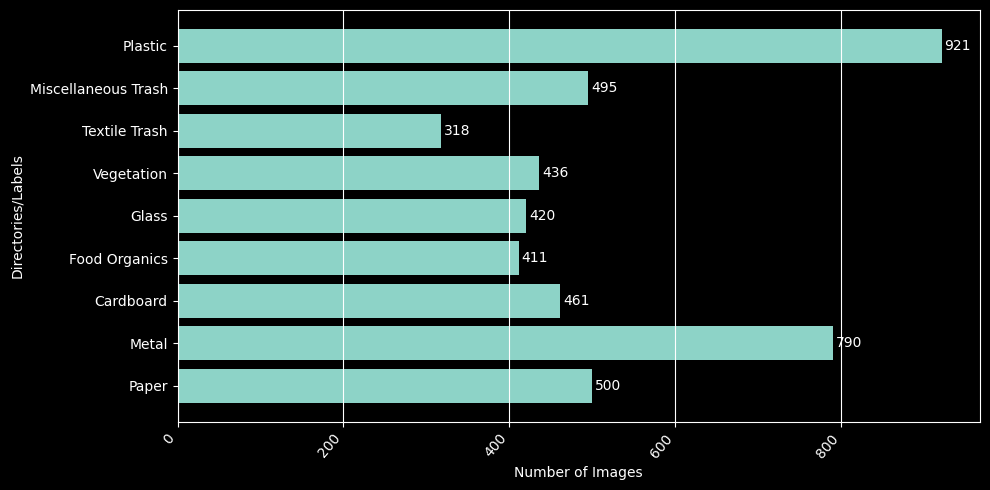

In [30]:
import matplotlib.pyplot as plt
def display_directory_bar_graph(path: Path)->None:
    # Initialize directories with number of files
    dirs_map: dict[str, int] = {}
    for root, _, files in os.walk(path, onerror=print):
        root_path = Path(root)
        if root_path.name != path.name:
            dirs_map[root_path.name] = len(files)
    # Plot bar graph containing files per directory
    plt.figure(figsize=[10, 5])
    bars = plt.barh(dirs_map.keys(), dirs_map.values())
    plt.bar_label(bars, padding=2)
    plt.ylabel('Directories/Labels')
    plt.xlabel('Number of Images')
    plt.xticks(rotation=50, ha='right')
    plt.grid(axis='x')
    plt.tight_layout()
    plt.show()

display_directory_bar_graph(real_waste_path)

#### Image Sample Per Label

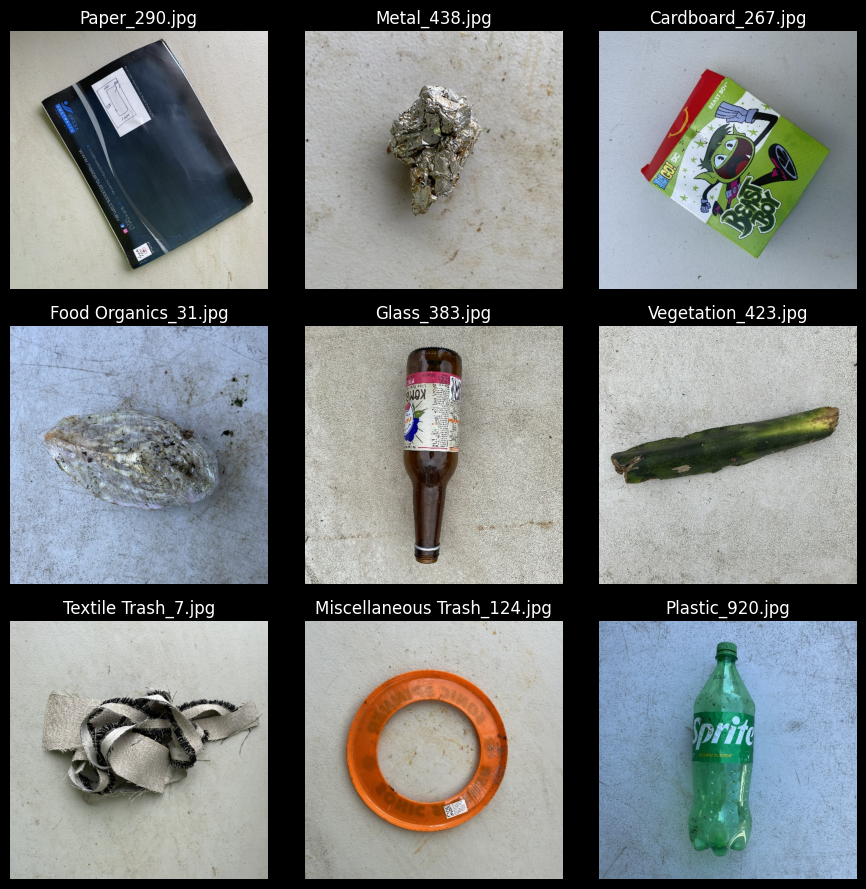

In [31]:
from PIL import Image
import random
import math

def display_random_image_per_dir(path: Path) -> None:
    image_paths = []
    for root, dirs, files in os.walk(path, onerror=print):
        root_path = Path(root)
        if root_path.name != path.name and files:
            image_name: str = random.choice(files)
            if image_name.endswith('.jpg'):
                image_paths.append(root_path/image_name)

    images_length = len(image_paths)
    cols = int(math.sqrt(images_length))
    rows = int(math.ceil(images_length / cols))

    plt.figure(figsize=[cols * 3, rows * 3])
    for i, path in enumerate(image_paths):
        img = Image.open(path)
        plt.subplot(rows, cols, i+1)
        plt.title(path.name)
        plt.imshow(img)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


display_random_image_per_dir(real_waste_path)

## Prepare the Data for Machine Learning Algorithms

### Split Data
Split data into standard split. Three distinct sets: Training, Validation, and Test.

In [32]:
from typing import Tuple
from torchvision import datasets, transforms
# See GitHub for more details on past commits:
# Previously, a random_split was used. However, for our purposes we are switching from
# using "random_split" to use "Subsets"
# so that we can apply different transforms to the trainings sets vs. the validation and test datasets.
from torch.utils.data import DataLoader, Subset
from pathlib import Path

NORMALIZE_MEAN = [0.5, 0.5, 0.5]
NORMALIZE_STD = [0.5, 0.5, 0.5]

def get_regular_transform() -> transforms.Compose:
    return transforms.Compose([
        transforms.Resize((224, 224)),  # Recommended 224x224 for CNNs
        transforms.ToTensor(),          # Convert Numpy/Image to Tensor
        # Normalize color channels
        transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
    ])

def get_augmented_transform() -> transforms.Compose:
    return transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
        transforms.RandomPerspective(distortion_scale=0.15, p=0.2),
        transforms.ToTensor(),          # Convert Numpy/Image to Tensor
        # Normalize color channels
        transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
    ])

def get_realwaste_dataloaders(data_path: Path, train_transform: transforms.Compose, batch_size: int=32, seed: int=42) -> Tuple[DataLoader, DataLoader, DataLoader, list[str]]:
    # We can do Data Augmentation here.
    # See Notes in GitHub Projects and Screenshots for more details and sources
    # We previously have had a single transform for all datasets, but need different transforms as follows:
    # 1. training: data augmentation techniques such as random cropping, horizontal flipping, rotation, color jittering, perspective transformation, etc.
    # 2. validation and test datasets: only resizing, tensor conversion, and normalization (no augmentation)
    train_ratio = 0.8
    val_ratio = 0.1

    # Automatic gets the datasets and its labels based on images structured in subdirectories

    # Base dataset: used only to get class names and total size
    base_dataset = datasets.ImageFolder(root=data_path)
    class_names = base_dataset.classes
    total_samples = len(base_dataset)
    reg_transform = get_regular_transform()

    # Full datasets with different transforms
    transform = get_augmented_transform()
    full_train_dataset = datasets.ImageFolder(root=data_path, transform=train_transform)
    full_validation_dataset = datasets.ImageFolder(root=data_path, transform=reg_transform)
    full_test_dataset = datasets.ImageFolder(root=data_path, transform=reg_transform)

    # Calculate dataset sizes
    train_size = int(train_ratio * total_samples)
    validation_size = int(val_ratio * total_samples)
    test_size = total_samples - train_size - validation_size

    # previously we had only one dataset that contained all data including training, validation and test data
    # so now we split randomly based on indexes to create subsets for training, validation and test datasets with different transforms

    # For example, if indices becomes
    # [5, 2, 0, 1, 4, 3] and train_size=3, validation_size=2, test_size=1
    # then train_indices = [5, 2, 0], val_indices = [1, 4], test_indices = [3]

    indices = torch.randperm(
    total_samples,
    generator=torch.Generator().manual_seed(seed)
    ).tolist()

    train_indices = indices[:train_size]
    validation_indices = indices[train_size:train_size + validation_size]
    test_indices = indices[train_size + validation_size:]

    # Choose training, validation, and test datasets
    train_dataset = Subset(full_train_dataset, train_indices)
    validation_dataset = Subset(full_validation_dataset, validation_indices)
    test_dataset = Subset(full_test_dataset, test_indices)

    # Prepare Data Loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # before we returned the fullDataSet.classes, but now we have a separate base dataset that is only used to get the class names, so we return the class names instead of full_dataset.classes

    return train_loader, validation_loader, test_loader, class_names

### Get Dataset Loaders

In [33]:
train_loader, validation_loader, test_loader, class_names = get_realwaste_dataloaders(real_waste_path, get_regular_transform())

### Visualize a Batch of Training Data

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import math

def show_image(img: np.ndarray):
    mean = np.array(NORMALIZE_MEAN).reshape(-1, 1, 1)
    std = np.array(NORMALIZE_STD).reshape(-1, 1, 1)
    img = img * std + mean

    plt.imshow(np.transpose(img, (1, 2, 0)))

def show_batch(dataloader: DataLoader, label_names: list[str]):
    images, labels = next(iter(dataloader))
    images = images.numpy()

    batch_size = len(images)
    cols = int(math.sqrt(batch_size))
    rows = int(math.ceil(batch_size / cols))

    fig = plt.figure(figsize=(12,12))

    for i in range(batch_size):
        ax = fig.add_subplot(rows, cols, i+1)
        show_image(images[i])
        ax.set_title(label_names[labels[i]])
        ax.axis('off')

    plt.tight_layout()
    plt.show()

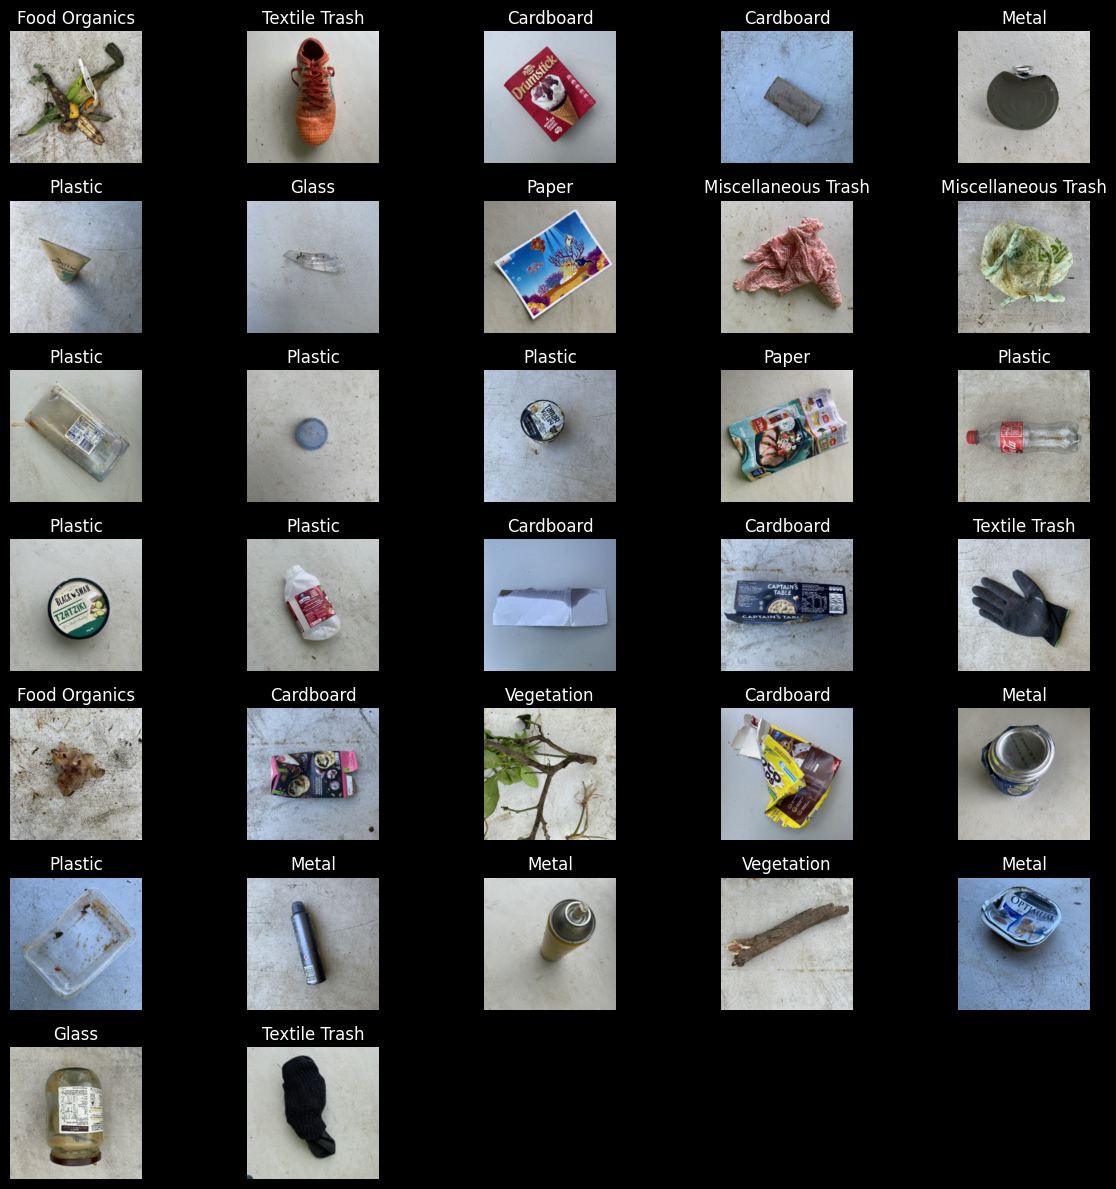

In [35]:
show_batch(test_loader, class_names)


## Select and Train Models

Reference: Using the layout for transfer learning from "Hands-On Machine Learning with Scikit-Learn and PyTorch" by Aurélien Géron
Chapter 12 Deep Computer Vision Using Convolutional Neural Networks

### Select Optimal Device

In [36]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Using device:', device)

Using device: mps


### TODO: Create Training Function

In [43]:
def train_model(model, train_loader: DataLoader, validation_loader: DataLoader, optimizer: torch.optim.Optimizer, loss_fn: torch.nn.modules.loss._Loss, epochs: int, device: torch.device ):
    pass

TODO: Train model for 5 or more epochs

### MobileNet v3 Small Transfer Learning

#### Download Weights and Model

In [37]:
mnv3_weights = torchvision.models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
mnv3_model = torchvision.models.mobilenet_v3_small(weights=mnv3_weights) # Set pretrained weights

#### Get Data for Training

In [40]:
mnv3_transform = mnv3_weights.transforms()
mnv3_train, mnv3_val, mnv3_test, class_names = get_realwaste_dataloaders(real_waste_path, mnv3_transform)

#### Replace Model's Head Layer (Output/Classifier)

Display the last layer that we will replace

In [41]:
mnv3_model.classifier[-1]

Linear(in_features=1024, out_features=1000, bias=True)

In [42]:
import torch.nn as nn
real_waste_class_len = len(class_names)
mnv3_model.classifier[-1] = nn.Linear(1024, real_waste_class_len, bias=True)

#### Freeze All Weights

In [ ]:
for param in mnv3_model.parameters():
    param.requires_grad = False

#### Unfreeze Classification/Head Weights

In [ ]:
for param in mnv3_model.classifier.parameters():
    param.requires_grad = True

## Fine-Tune Models

TODO: Unfreeze extra layers starting from the top

TODO: Compare with Data Augmentation

TODO: Try different Optimizers

## Save Optimal Model